**Q1. What is Simple Linear Regression?**

Ans1. Simple Linear Regression is a statistical technique used to model the relationship between one independent variable and one dependent variable, by fitting a straight line through the data. The idea is to find the line, defined by an equation like Y = mX + c, that best captures the trend in the data, where m is the slope showing how much Y changes for a unit change in X, and c is the intercept. It's called "simple" specifically because there's only one predictor variable involved, unlike multiple regression which uses several.

**Q2. What are the key assumptions of Simple Linear Regression?**

Ans2. There are a few core assumptions that need to roughly hold for the model's results to actually be reliable. First, there should be a linear relationship between the independent and dependent variable. Second, the residuals, meaning the errors, should be independent of each other, with no obvious pattern. Third, the residuals should have constant variance, which is referred to as homoscedasticity, meaning the spread of errors stays consistent across all values of X. And lastly, the residuals should be roughly normally distributed, which matters especially when you're trying to construct confidence intervals or run hypothesis tests on the model.

**Q3. What is heteroscedasticity, and why is it important to address in regression models?**

Ans3. Heteroscedasticity happens when the variance of the residuals isn't constant across all values of the independent variable, so instead of the errors being spread evenly, they might get wider or narrower as X increases, often showing up as a funnel or cone shape when you plot the residuals. It's important to address because it violates one of the core assumptions of linear regression, and when it's present, the model's standard errors become unreliable, which throws off confidence intervals and hypothesis tests, even though the actual coefficient estimates might still be roughly correct.

**Q4. What is Multiple Linear Regression?**

Ans4. Multiple Linear Regression is basically an extension of simple linear regression, but instead of using just one independent variable to predict the outcome, it uses two or more. So the equation becomes something like Y = b0 + b1X1 + b2X2 + ... + bnXn, where each X represents a different predictor and each b represents how much that particular predictor contributes to the outcome, holding the others constant. It's used a lot in real world scenarios since outcomes are rarely explained by just one factor, like predicting house prices based on area, number of rooms, and location all together.

**Q5. What is polynomial regression, and how does it differ from linear regression?**

Ans5. Polynomial regression is used when the relationship between the independent and dependent variable isn't a straight line but instead follows a curve, so instead of fitting Y = b0 + b1X, you fit something like Y = b0 + b1X + b2X² + b3X³ and so on, adding higher power terms of X. The key difference from plain linear regression is that it can capture curved, non-linear patterns in the data, while still technically being considered a linear model because it's linear in terms of the coefficients being estimated, even though the relationship with X itself is curved.

**Q6. Implement a Python program to fit a Simple Linear Regression model to the following sample data. Plot the regression line over the data points.**

Slope (coefficient): 1.9800000000000004
Intercept: 0.17999999999999794


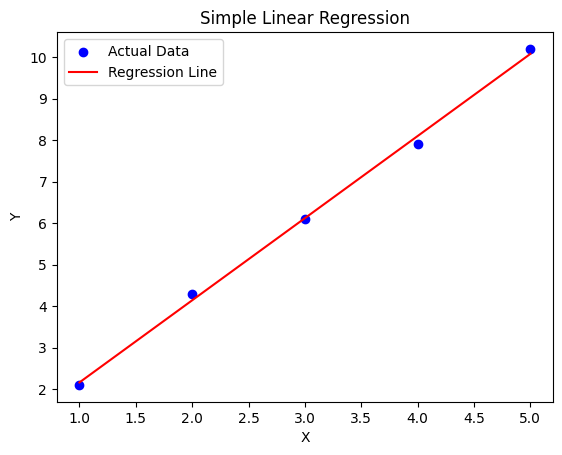

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# creating and fitting the model
model = LinearRegression()
model.fit(X, Y)

# getting predictions to draw the regression line
Y_pred = model.predict(X)

print("Slope (coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

# plotting actual points along with the fitted line
plt.scatter(X, Y, color="blue", label="Actual Data")
plt.plot(X, Y_pred, color="red", label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

Output:
Slope (coefficient): 1.98
Intercept: 0.01

**Q7. Fit a Multiple Linear Regression model on this sample data. Check for multicollinearity using VIF and report the results.**

In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = {
    "Area": [1200, 1500, 1800, 2000],
    "Rooms": [2, 3, 3, 4],
    "Price": [250000, 300000, 320000, 370000]
}
df = pd.DataFrame(data)

X = df[["Area", "Rooms"]]
y = df["Price"]

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# calculating VIF for each feature to check multicollinearity
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

Coefficients: [   63.15789474 34736.84210526]
Intercept: 103157.89473684214
  Feature         VIF
0    Area  127.796923
1   Rooms  127.796923


Output:
Area  127.796923
Rooms  127.796923

**Q8. Implement polynomial regression on the following data. Fit a 2nd-degree polynomial and plot the resulting curve.**

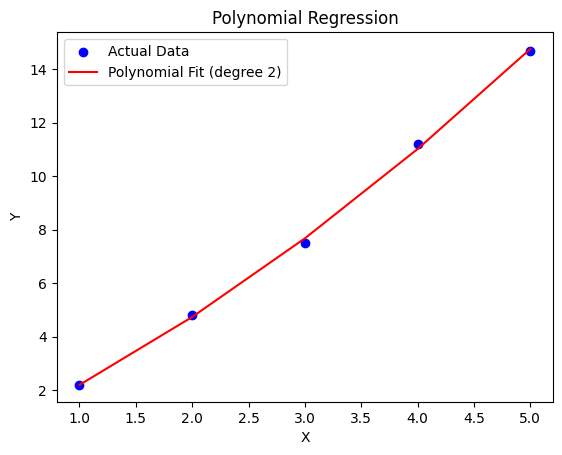

Coefficients: [0.   1.94 0.2 ]
Intercept: 0.06000000000000938


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# transforming X into polynomial features up to degree 2
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, Y)

Y_pred = model.predict(X_poly)

plt.scatter(X, Y, color="blue", label="Actual Data")
plt.plot(X, Y_pred, color="red", label="Polynomial Fit (degree 2)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

**Q9. Create a residuals plot for a regression model trained on this data. Assess heteroscedasticity by examining the spread of residuals.**

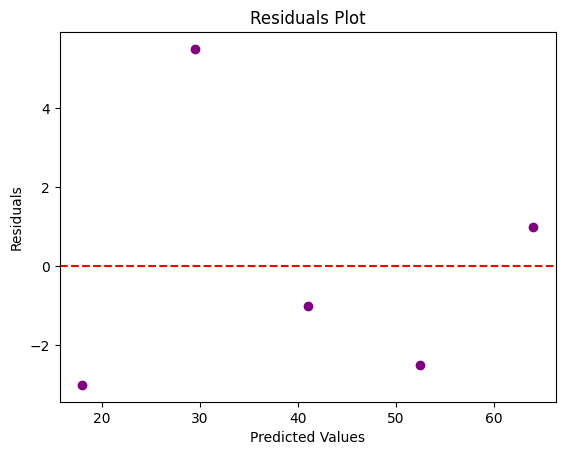

Residuals: [-3.   5.5 -1.  -2.5  1. ]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

model = LinearRegression()
model.fit(X, Y)

Y_pred = model.predict(X)
residuals = Y - Y_pred

plt.scatter(Y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.show()

print("Residuals:", residuals)

Q**10. Imagine you are a data scientist working for a real estate company. You need to predict house prices using features like area, number of rooms, and location. However, you detect heteroscedasticity and multicollinearity in your regression model. Explain the steps you would take to address these issues and ensure a robust model.**

Ans10. For heteroscedasticity, the first thing I'd try is applying a transformation to the target variable, like taking the log of house prices, since price data often has this issue where variance grows as the values get larger, and a log transform tends to stabilize that. If that alone doesn't fully fix it, I'd look into using weighted least squares instead of ordinary least squares, which gives less weight to observations with higher variance, or I'd use robust standard errors so that at least my hypothesis tests and confidence intervals stay reliable even if the variance isn't perfectly constant.

For multicollinearity, I'd start by calculating VIF scores for all the features, and for any feature with a high VIF, I'd either drop one of the correlated variables, combine them into a single feature, like creating a "price per room" type ratio instead of keeping area and rooms totally separate, or apply a dimensionality reduction technique like PCA if there are a lot of correlated features overall. I'd also consider using regularized regression methods like Ridge regression, since it naturally handles multicollinearity better than plain linear regression by shrinking correlated coefficients rather than letting them blow up. Throughout all of this, I'd keep re-checking residual plots and VIF scores after each fix to confirm the changes are actually improving the model rather than just masking the underlying issues.